## Analizo de la krado

La kodo implementas **7-segmentan enkodigan sistemon** por krado el du kvadratoj 1×1 starigitaj unu super alia.

### Strukturo de la krado

```
(0,2)──a──(1,2)
  |           |
  b           d
  |           |
(0,1)──i──(1,1)
  |           |
  p           q
  |           |
(0,0)──u──(1,0)
```

### 7 segmentoj

| Nomo | Tipo        | Pozicio          |
|------|-------------|------------------|
| `u`  | horizontala | malsupra         |
| `i`  | horizontala | meza             |
| `a`  | horizontala | supra            |
| `p`  | vertikala   | maldekstra malsupra |
| `b`  | vertikala   | maldekstra supra |
| `q`  | vertikala   | dekstra malsupra |
| `d`  | vertikala   | dekstra supra    |

### Enhavo de la ĉeloj

**Ĉelo 2** — Bazaj difinoj:
- `EDGES` ligas ĉiun literon al liniosegmento inter du verticoj
- `decode(s)` konvertas literĉenon (ekz. `"abiqu"`) al aro de aktivaj segmentaj indeksoj
- `visualize(s)` desegnas ununuran figuron: aktivaj segmentoj en nigra, neaktivaj en punkta grizo

**Ĉelo 3** — Kombinatoria superrigardo:
- Iteras tra ĉiuj C(7,k) kombinaĵoj por k ∈ {7, 6, 5, 4}
- Sumo: 1 + 7 + 21 + 35 = **64 figuroj** entute
- Bildigos ĉiun grupon en krada aranĝo kun etikedoj

Vizualizacio: 'abiqu'


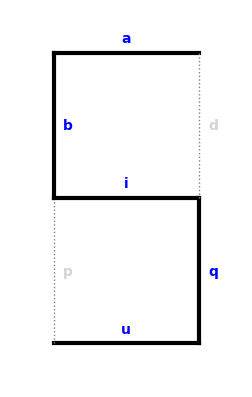

In [51]:
import matplotlib.pyplot as plt

# --- 7-segmenta krado 1×2 ---
# 7 segmentoj: 3 horizontalaj + 4 vertikalaj
LETTERS = ['u', 'i', 'a', 'p', 'b', 'q', 'd']
letter_to_idx = {ch: i for i, ch in enumerate(LETTERS)}
idx_to_letter = {i: ch for i, ch in enumerate(LETTERS)}

# Koordinatoj: verteksoj (0,0),(1,0),(0,1),(1,1),(0,2),(1,2)
EDGES = [
    ((0, 0), (1, 0)),  # 0: u - malsupra horizontala
    ((0, 1), (1, 1)),  # 1: i - meza horizontala
    ((0, 2), (1, 2)),  # 2: a - supra horizontala
    ((0, 0), (0, 1)),  # 3: p - maldekstra malsupra vertikala
    ((0, 1), (0, 2)),  # 4: b - maldekstra supra vertikala
    ((1, 0), (1, 1)),  # 5: q - dekstra malsupra vertikala
    ((1, 1), (1, 2)),  # 6: d - dekstra supra vertikala
]


def decode(letter_string: str) -> set:
    result = set()
    for ch in letter_string:
        if ch not in letter_to_idx:
            raise ValueError(f"Nekonata simbolo '{ch}'. Permesataj: {LETTERS}")
        result.add(letter_to_idx[ch])
    return result


def visualize(letter_string: str, ax=None):
    present = decode(letter_string)
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 5))

    for i, ((x1, y1), (x2, y2)) in enumerate(EDGES):
        if i in present:
            color = 'black'
            linestyle = '-'
            linewidth = 3
        else:
            color = 'gray'
            linestyle = 'dotted'
            linewidth = 1

        ax.plot([x1, x2], [y1, y2], color=color, linestyle=linestyle, linewidth=linewidth)

        mx = (x1 + x2) / 2
        my = (y1 + y2) / 2
        if y1 == y2:  # horizontala
            offset_x, offset_y = 0, 0.1
        else:         # vertikala
            offset_x, offset_y = 0.1, 0

        text_color = 'blue' if i in present else 'lightgray'
        ax.text(mx + offset_x, my + offset_y, idx_to_letter[i],
                fontsize=10, ha='center', va='center',
                color=text_color, fontweight='bold')

    ax.set_aspect('equal')
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 2.3)
    ax.axis('off')
    ax.set_frame_on(False)
    plt.show()


# Demonstrado
test_str = 'abiqu'
print(f"Vizualizacio: '{test_str}'")
visualize(test_str)


In [ ]:
from itertools import combinations


def draw_figure(ax, letter_string, x_offset=0.15, y_offset=0.15, cell_size=0.6):
    """Vizualizas unu 7-segmentan figuron en donita ax."""
    present = decode(letter_string)
    for i, ((x1, y1), (x2, y2)) in enumerate(EDGES):
        xx1 = x_offset + x1 * cell_size
        yy1 = y_offset + y1 * cell_size
        xx2 = x_offset + x2 * cell_size
        yy2 = y_offset + y2 * cell_size
        if i in present:
            ax.plot([xx1, xx2], [yy1, yy2], "k-", linewidth=1.5)
        else:
            ax.plot(
                [xx1, xx2], [yy1, yy2], color="gray", linestyle="dotted", linewidth=0.6
            )
    label = "'" + letter_string + "'" if letter_string else "''"
    ax.text(
        x_offset + 0.5 * cell_size,
        y_offset - 0.1,
        label,
        fontsize=8,
        ha="center",
        va="top",
        family="monospace",
    )


def visualize_group(combos, title, max_cols=10):
    """Vizualizas grupon de figuroj: unu figuro per subploto."""
    n = len(combos)
    cols = min(n, max_cols)
    rows = (n + cols - 1) // cols

    fig_width = cols * 1.1 + 0.5
    fig_height = rows * 2.2 + 0.8

    fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height), squeeze=False)
    fig.suptitle(title, fontsize=11, fontweight="bold")

    for idx in range(n):
        r, c = divmod(idx, cols)
        ax = axes[r][c]
        draw_figure(ax, combos[idx])
        ax.set_xlim(0, 1.1)
        ax.set_ylim(-0.4, 1.6)
        ax.set_aspect("equal")
        ax.axis("off")

    for idx in range(rows * cols):
        r, c = divmod(idx, cols)
        if idx >= n:
            axes[r][c].axis("off")

    plt.tight_layout()
    plt.show()
    print()


# Grupoj laŭ nombro de sekcioj: 7, 6, 5, 4
for k in [7, 6, 5, 4]:
    combos = [
        "".join(idx_to_letter[i] for i in sorted(indices))
        for indices in combinations(range(7), k)
    ]
    title = f"{k} sekcioj  |  {len(combos)} figuroj"
    print(title)
    print("=" * 60)
    visualize_group(combos, title, max_cols=10)


## 10-segmenta krado 1×3

Etendaĵo al **tri kvadratoj** starigitaj unu super alia. La supra kaj malsupra kvadratoj konservas la originajn kodojn; la nova meza kvadrato aldonas tri segmentojn.

### Strukturo de la krado

```
(0,3)──a──(1,3)
  |           |
  b           d
  |           |
(0,2)──i──(1,2)
  |           |
  l           r
  |           |
(0,1)──o──(1,1)
  |           |
  p           q
  |           |
(0,0)──u──(1,0)
```

### 10 segmentoj

| Nomo | Tipo        | Pozicio                  |
|------|-------------|--------------------------|
| `u`  | horizontala | malsupra                 |
| `o`  | horizontala | meza-malsupra  *(nova)*  |
| `i`  | horizontala | meza-supra  *(nova)*     |
| `a`  | horizontala | supra                    |
| `p`  | vertikala   | maldekstra malsupra      |
| `l`  | vertikala   | maldekstra meza  *(nova)*|
| `b`  | vertikala   | maldekstra supra         |
| `q`  | vertikala   | dekstra malsupra         |
| `r`  | vertikala   | dekstra meza  *(nova)*   |
| `d`  | vertikala   | dekstra supra            |

### Kombinatoria superrigardo

Montrataj grupoj laŭ nombro de sekcioj (k ∈ {10, 9, 8, 7, 6, 5}):

| k  | C(10,k) | noto                              |
|----|---------|-----------------------------------|
| 10 | 1       | ĉiuj sekcioj                      |
| 9  | 10      | inverso de 1-sekciaj figuroj      |
| 8  | 45      | inverso de 2-sekciaj figuroj      |
| 7  | 120     | inverso de 3-sekciaj figuroj      |
| 6  | 210     | inverso de 4-sekciaj figuroj      |
| 5  | 252     | plej granda grupo (simetria mezo) |
| **Sumo** | **638** | |

> Figuroj kun 1–4 sekcioj estas inversoj (komplementoj) de figuroj kun 9–6 sekcioj, do ili ne aldonas novajn formojn.

Vizualizacio: 'abiropu'


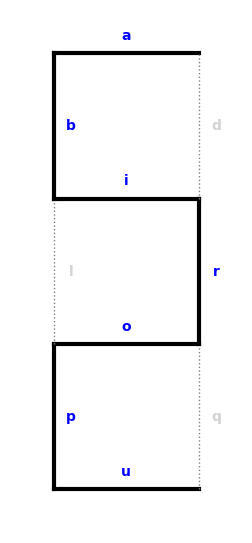

In [53]:
import matplotlib.pyplot as plt

# --- 10-segmenta krado 1×3 ---
# 10 segmentoj: 4 horizontalaj + 6 vertikalaj
LETTERS_3 = ['u', 'o', 'i', 'a', 'p', 'l', 'b', 'q', 'r', 'd']
letter_to_idx_3 = {ch: i for i, ch in enumerate(LETTERS_3)}
idx_to_letter_3 = {i: ch for i, ch in enumerate(LETTERS_3)}

# Koordinatoj: verteksoj (0,0)...(1,3)
EDGES_3 = [
    ((0, 0), (1, 0)),  # 0: u - malsupra horizontala
    ((0, 1), (1, 1)),  # 1: o - meza-malsupra horizontala
    ((0, 2), (1, 2)),  # 2: i - meza-supra horizontala
    ((0, 3), (1, 3)),  # 3: a - supra horizontala
    ((0, 0), (0, 1)),  # 4: p - maldekstra malsupra vertikala
    ((0, 1), (0, 2)),  # 5: l - maldekstra meza vertikala
    ((0, 2), (0, 3)),  # 6: b - maldekstra supra vertikala
    ((1, 0), (1, 1)),  # 7: q - dekstra malsupra vertikala
    ((1, 1), (1, 2)),  # 8: r - dekstra meza vertikala
    ((1, 2), (1, 3)),  # 9: d - dekstra supra vertikala
]


def decode_3(letter_string: str) -> set:
    result = set()
    for ch in letter_string:
        if ch not in letter_to_idx_3:
            raise ValueError(f"Nekonata simbolo '{ch}'. Permesataj: {LETTERS_3}")
        result.add(letter_to_idx_3[ch])
    return result


def visualize_3(letter_string: str, ax=None):
    present = decode_3(letter_string)
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 7))

    for i, ((x1, y1), (x2, y2)) in enumerate(EDGES_3):
        if i in present:
            color = 'black'
            linestyle = '-'
            linewidth = 3
        else:
            color = 'gray'
            linestyle = 'dotted'
            linewidth = 1

        ax.plot([x1, x2], [y1, y2], color=color, linestyle=linestyle, linewidth=linewidth)

        mx = (x1 + x2) / 2
        my = (y1 + y2) / 2
        if y1 == y2:  # horizontala
            offset_x, offset_y = 0, 0.12
        else:          # vertikala
            offset_x, offset_y = 0.12, 0

        text_color = 'blue' if i in present else 'lightgray'
        ax.text(mx + offset_x, my + offset_y, idx_to_letter_3[i],
                fontsize=10, ha='center', va='center',
                color=text_color, fontweight='bold')

    ax.set_aspect('equal')
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 3.3)
    ax.axis('off')
    ax.set_frame_on(False)
    plt.show()


# Demonstrado
test_str_3 = 'abiropu'
print(f"Vizualizacio: '{test_str_3}'")
visualize_3(test_str_3)


In [ ]:
from itertools import combinations


def draw_figure_3(ax, letter_string, x_offset=0.15, y_offset=0.15, cell_size=0.6):
    """Vizualizas unu 10-segmentan figuron en donita ax."""
    present = decode_3(letter_string)
    for i, ((x1, y1), (x2, y2)) in enumerate(EDGES_3):
        xx1 = x_offset + x1 * cell_size
        yy1 = y_offset + y1 * cell_size
        xx2 = x_offset + x2 * cell_size
        yy2 = y_offset + y2 * cell_size
        if i in present:
            ax.plot([xx1, xx2], [yy1, yy2], "k-", linewidth=1.5)
        else:
            ax.plot(
                [xx1, xx2], [yy1, yy2], color="gray", linestyle="dotted", linewidth=0.6
            )
    label = "'" + letter_string + "'" if letter_string else "''"
    ax.text(
        x_offset + 0.5 * cell_size,
        y_offset - 0.1,
        label,
        fontsize=6,
        ha="center",
        va="top",
        family="monospace",
    )


def visualize_group_3(combos, title, max_cols=10):
    """Vizualizas grupon de 10-segmentaj figuroj."""
    n = len(combos)
    cols = min(n, max_cols)
    rows = (n + cols - 1) // cols

    fig_width = cols * 1.1 + 0.5
    fig_height = rows * 3.2 + 0.8

    fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height), squeeze=False)
    fig.suptitle(title, fontsize=11, fontweight="bold")

    for idx in range(n):
        r, c = divmod(idx, cols)
        ax = axes[r][c]
        draw_figure_3(ax, combos[idx])
        ax.set_xlim(0, 1.1)
        ax.set_ylim(-0.3, 2.1)
        ax.set_aspect("equal")
        ax.axis("off")

    for idx in range(rows * cols):
        r, c = divmod(idx, cols)
        if idx >= n:
            axes[r][c].axis("off")

    plt.tight_layout()
    plt.show()
    print()


# Grupoj laŭ nombro de sekcioj: 10, 9, 8, 7, 6, 5
# (figuroj kun 1–4 sekcioj estas inversoj de figuroj kun 9–6 sekcioj)
for k in [10, 9, 8, 7, 6, 5]:
    combos = [
        "".join(idx_to_letter_3[i] for i in sorted(indices))
        for indices in combinations(range(10), k)
    ]
    title = f"{k} sekcioj  |  {len(combos)} figuroj"
    print(title)
    print("=" * 60)
    visualize_group_3(combos, title, max_cols=10)


In [55]:
# --- Komunaj konstantoj kaj helpfunkcioj por literaj kradoj ---

EO_LITEROJ = [
    'a',  'b',   'c',   'ĉ',  'd',  'e',  'f',  'g',
    'ĝ',  'h',   'ĥ',   'i',  'j',  'ĵ',  'k',  'l',
    'm',  'n',   'o',   'p',  'r',  's',  'ŝ',  't',
    'u',  'ŭ',   'v',   'z',  '-j', '-n', '-jn','-s',
    '-ŭ', '-eŭ', '-',   "'",  '_',  ',',  '=',  '.',
]

COLS = 8
ROWS = 5


def draw_placeholder(ax, litero, edges, grid_height, x_offset=0.15, y_offset=0.15, cell_size=0.6):
    """Draws an empty (all-dotted) grid with the Esperanto letter label above."""
    for (x1, y1), (x2, y2) in edges:
        xx1 = x_offset + x1 * cell_size
        yy1 = y_offset + y1 * cell_size
        xx2 = x_offset + x2 * cell_size
        yy2 = y_offset + y2 * cell_size
        ax.plot([xx1, xx2], [yy1, yy2], color="lightgray", linestyle="dotted", linewidth=0.8)
    top_y = y_offset + grid_height * cell_size
    ax.text(
        x_offset + 0.5 * cell_size,
        top_y + 0.06,
        litero,
        fontsize=11,
        ha="center",
        va="bottom",
        fontweight="bold",
    )


def draw_letter(ax, litero, kodo, edges, decode_fn, grid_height,
                x_offset=0.15, y_offset=0.15, cell_size=0.6):
    """Draws a grid: known segments in black, unknown dotted. Letter label above."""
    present = decode_fn(kodo) if kodo else set()
    for i, ((x1, y1), (x2, y2)) in enumerate(edges):
        xx1 = x_offset + x1 * cell_size
        yy1 = y_offset + y1 * cell_size
        xx2 = x_offset + x2 * cell_size
        yy2 = y_offset + y2 * cell_size
        if i in present:
            ax.plot([xx1, xx2], [yy1, yy2], "k-", linewidth=1.5)
        else:
            ax.plot([xx1, xx2], [yy1, yy2], color="lightgray", linestyle="dotted", linewidth=0.8)
    top_y = y_offset + grid_height * cell_size
    ax.text(
        x_offset + 0.5 * cell_size,
        top_y + 0.06,
        litero,
        fontsize=9,
        ha="center",
        va="bottom",
        fontweight="bold",
        color="black" if kodo else "lightgray",
    )


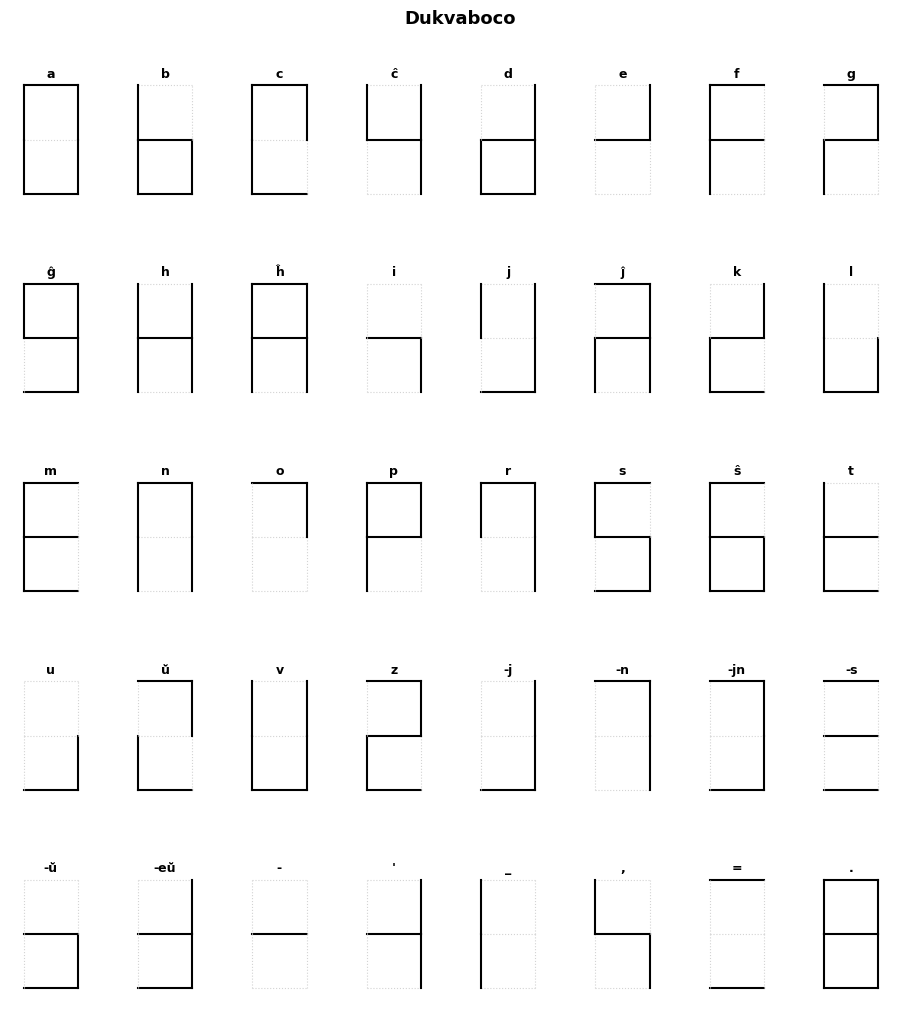

In [56]:
# Konataj kodoj por 1×2 krado
KODOJ_2 = {
    'a': 'abpuqd',
    'b': 'bipuq',
    'c': 'dabpu',
    'ĉ': 'bidq',
    'd': 'dipuq',
    'e': 'id',
    'f': 'abip',
    'g': 'adip',
    
    'ĝ': 'abidqu',
    'h': 'bidpq',
    'ĥ': 'abidpq',
    'i': 'iq',
    'j': 'bdqu',
    'ĵ': 'adipq',
    'k': 'dipu',
    'l': 'bpuq',

    'm': 'abipu',
    'n': 'apbdpq',
    'o': 'ad',
    'p': 'abidp',
    'r': 'abdq',
    's': 'abiqu',
    'ŝ': 'abipuq',
    't': 'bipu',
    
    'u': 'qu',
    'ŭ': 'adpu',
    'v': 'bdpuq',
    'z': 'adipu',
    '-j': 'duq',
    '-n': 'adq',
    '-jn': 'aduq',
    '-s': 'aiu',

    '-ŭ': 'iqu',
    '-eŭ': 'diqu',
    '-': 'i',
    "'": 'diq',
    "_": 'bp',
    ",": 'biq',
    "=": 'au',
    ".": 'abidpuq',
}

# --- 1×2 krado ---
def montru_abocon_1_2():
    fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 1.1 + 0.5, ROWS * 2.0 + 0.6), squeeze=False)
    fig.suptitle("Dukvaboco", fontsize=13, fontweight="bold")

    for idx, litero in enumerate(EO_LITEROJ):
        r, c = divmod(idx, COLS)
        ax = axes[r][c]
        draw_letter(ax, litero, KODOJ_2.get(litero, ''), EDGES, decode, grid_height=2)
        ax.set_xlim(0, 1.1)
        ax.set_ylim(-0.1, 1.65)
        ax.set_aspect("equal")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

montru_abocon_1_2()

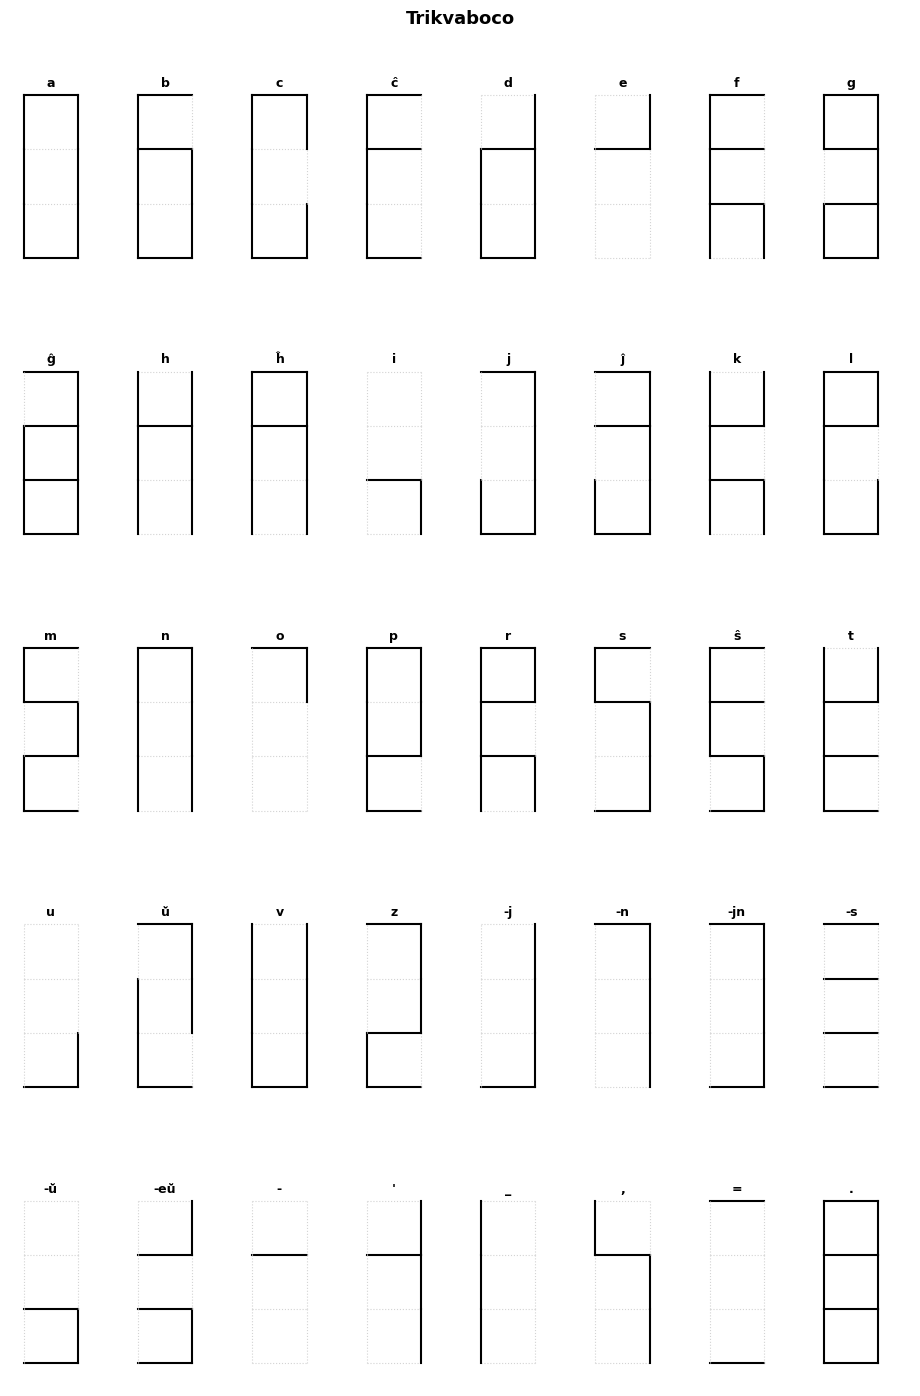

In [57]:
# --- 1×3 krado ---
KODOJ_3 = {
    'a': 'abdlrpuq',
    'b': 'abilrpuq',
    'c': 'abdlpuq',
    'ĉ': 'abilpu',
    'd': 'dilrpuq',
    'e': 'id',
    'f': 'abilopq',
    'g': 'abdiropuq',
    
    'ĝ': 'adilorpuq',
    'h': 'bidlrpq',
    'ĥ': 'abidlrpq',
    'i': 'oq',
    'j': 'adrpuq',
    'ĵ': 'adirpuq',
    'k': 'bidlpoq',
    'l': 'abidlpuq',

    'm': 'abiropu',
    'n': 'abdlrpq',
    'o': 'ad',
    'p': 'abdlorpu',
    'r': 'abidlopq',
    's': 'abirqu',
    'ŝ': 'abilouq',
    't': 'bidlopu',

    'u': 'qu',
    'ŭ': 'adlrpu',
    'v': 'bdlrpuq',
    'z': 'adropu',
    '-j': 'druq',
    '-n': 'adrq',
    '-jn': 'adruq',
    '-s': 'aiou',

    '-ŭ': 'ouq',
    '-eŭ': 'idouq',
    '-': 'i',
    "'": 'dirq',
    "_": 'blp',
    ",": 'birq',
    "=": 'au',
    ".": 'abidlorpuq',
    
}

def montru_abocon_1_3():
    fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 1.1 + 0.5, ROWS * 2.8 + 0.6), squeeze=False)
    fig.suptitle("Trikvaboco", fontsize=13, fontweight="bold")

    for idx, litero in enumerate(EO_LITEROJ):
        r, c = divmod(idx, COLS)
        ax = axes[r][c]
        draw_letter(ax, litero, KODOJ_3.get(litero, ''), EDGES_3, decode_3, grid_height=3)
        ax.set_xlim(0, 1.1)
        ax.set_ylim(-0.1, 2.25)
        ax.set_aspect("equal")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

montru_abocon_1_3()
